In [1]:
import numpy as np
import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [2]:
data = np.load("pems08.npz")["data"]

traffic = data[:, :, 0]

print(traffic.shape)

(17856, 170)


In [3]:
scaler = MinMaxScaler()

traffic_scaled = scaler.fit_transform(
    traffic
)

print(
    traffic_scaled.shape
)

(17856, 170)


In [4]:
X = []
y = []

sequence_length = 12

for i in range(
    len(traffic_scaled)
    -
    sequence_length
):

    X.append(
        traffic_scaled[
            i:i+sequence_length
        ]
    )

    y.append(
        traffic_scaled[
            i+sequence_length
        ]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(17844, 12, 170)
(17844, 170)


In [5]:
train_size = int(len(X)*0.7)
val_size = int(len(X)*0.1)


X_train = X[:train_size]
y_train = y[:train_size]


X_val = X[
    train_size:
    train_size+val_size
]

y_val = y[
    train_size:
    train_size+val_size
]


X_test = X[
    train_size+val_size:
]

y_test = y[
    train_size+val_size:
]


print(X_train.shape)
print(X_test.shape)

(12490, 12, 170)
(3570, 12, 170)


In [6]:
import torch

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [7]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader


train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [8]:
import pickle
import numpy as np

with open("adj_mx_bay.pkl", "rb") as f:
    sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(
        f,
        encoding="latin1"
    )

print(adj_mx.shape)

print(adj_mx.min())
print(adj_mx.max())

(325, 325)
0.0
1.0


In [9]:
A = adj_mx

A = A + np.eye(A.shape[0])

D = np.diag(
    np.power(
        A.sum(axis=1),
        -0.5
    )
)

A_hat = D @ A @ D

print(A_hat.shape)

(325, 325)


In [10]:
import torch

A_hat = torch.tensor(
    A_hat,
    dtype=torch.float32
)

print(A_hat.shape)

torch.Size([325, 325])


In [11]:
class GraphConv(nn.Module):

    def __init__(
        self,
        num_nodes,
        in_features,
        out_features
    ):

        super().__init__()

        self.node_embeddings = nn.Parameter(
            torch.randn(
                num_nodes,
                16
            )
        )

        self.linear = nn.Linear(
            in_features,
            out_features
        )

    def forward(self,x):

        adj = torch.softmax(
            torch.relu(
                self.node_embeddings
                @
                self.node_embeddings.T
            ),
            dim=1
        )

        x = torch.einsum(
            "ij,btj->bti",
            adj,
            x
        )

        x = self.linear(x)

        return torch.relu(x)

In [12]:
class GCNLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.gcn = GraphConv(
            num_nodes=170,
            in_features=170,
            out_features=170
        )

        self.lstm = nn.LSTM(
            input_size=170,
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Linear(
            64,
            170
        )

    def forward(self,x):

        x = self.gcn(x)

        output, (hidden, cell) = self.lstm(x)

        hidden = hidden[-1]

        x = self.fc(hidden)

        return x

In [13]:
model = GCNLSTM()

X_batch, y_batch = next(iter(train_loader))

pred = model(X_batch)

print(pred.shape)
print(y_batch.shape)

torch.Size([64, 170])
torch.Size([64, 170])


In [14]:
model = GCNLSTM()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

import time

train_start = time.time()

epochs = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = (
        total_train_loss / len(train_loader)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    total_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            val_loss = criterion(
                predictions,
                y_batch
            )

            total_val_loss += val_loss.item()

    avg_val_loss = (
        total_val_loss / len(val_loader)
    )

    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            "STGCN-PEMS08-best.pth"
        )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Train Loss: {avg_train_loss:.6f} "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch 1/30 Train Loss: 0.022874 Val Loss: 0.011498
Epoch 2/30 Train Loss: 0.008182 Val Loss: 0.010212
Epoch 3/30 Train Loss: 0.007308 Val Loss: 0.009710
Epoch 4/30 Train Loss: 0.007009 Val Loss: 0.010038
Epoch 5/30 Train Loss: 0.006786 Val Loss: 0.009638
Epoch 6/30 Train Loss: 0.006466 Val Loss: 0.009272
Epoch 7/30 Train Loss: 0.006218 Val Loss: 0.008980
Epoch 8/30 Train Loss: 0.006030 Val Loss: 0.009015
Epoch 9/30 Train Loss: 0.005932 Val Loss: 0.008992
Epoch 10/30 Train Loss: 0.006027 Val Loss: 0.009239
Epoch 11/30 Train Loss: 0.005790 Val Loss: 0.008574
Epoch 12/30 Train Loss: 0.005451 Val Loss: 0.008359
Epoch 13/30 Train Loss: 0.005286 Val Loss: 0.008250
Epoch 14/30 Train Loss: 0.005260 Val Loss: 0.008204
Epoch 15/30 Train Loss: 0.005211 Val Loss: 0.008160
Epoch 16/30 Train Loss: 0.005147 Val Loss: 0.008114
Epoch 17/30 Train Loss: 0.005058 Val Loss: 0.008144
Epoch 18/30 Train Loss: 0.005014 Val Loss: 0.008288
Epoch 19/30 Train Loss: 0.004939 Val Loss: 0.008257
Epoch 20/30 Train Los

In [15]:
train_time= time.time() - train_start

print("Time Taken:", train_time)

Time Taken: 172.4522728919983


In [16]:
model.load_state_dict(
    torch.load(
        "STGCN-PEMS08-best.pth",
        map_location="cpu"
    )
)


<All keys matched successfully>

In [17]:
model.eval()

infer_start = time.time()

with torch.no_grad():

    predictions = model(
        X_test
    )

predictions = predictions.numpy()

infer_time = time.time() - infer_start
print("Infer Time:", infer_time)

true_values = y_test.numpy()

mae = mean_absolute_error(
    true_values,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        true_values,
        predictions
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

Infer Time: 0.16106367111206055
MAE: 0.048104178160429
RMSE: 0.07444082151968892


In [18]:
from sklearn.metrics import r2_score

mape = np.mean(
    np.abs((true_values - predictions) /
           np.maximum(np.abs(true_values), 1e-6))
) * 100

r2 = r2_score(
    true_values.flatten(),
    predictions.flatten()
)
print("MAPE:", mape)
print("R2:", r2)

MAPE: 27993.604
R2: 0.9105347990989685


In [19]:
params = sum(
    p.numel()
    for p in model.parameters()
)

print("Parameters:", params)

Parameters: 103256


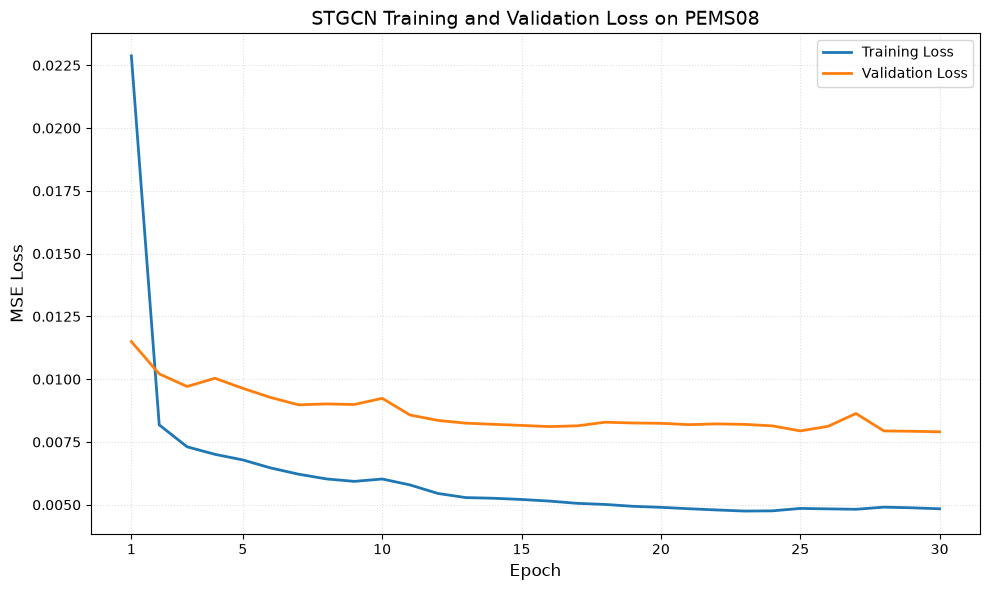

In [20]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_losses,
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)

plt.title(
    "STGCN Training and Validation Loss on PEMS08",
    fontsize=14
)

plt.xticks([1, 5, 10, 15, 20, 25, 30])

plt.grid(
    True,
    linestyle=":",
    alpha=0.4
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "STGCN-PEMS08-validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()